# Grafos

Vamos a utilizar la librería `networkx` para la utilización de grafos.

In [24]:
# !pip3 install networkx

### Grados no dirigidos

In [25]:
import networkx as nx
# Podemos crear un grafo con
G = nx.Graph()

In [26]:
G.add_node(1)
G.add_nodes_from([2, 3, 4, 5, 6])

In [27]:
print(G.nodes)
for node in G.nodes:
    print(node)


[1, 2, 3, 4, 5, 6]
1
2
3
4
5
6


In [28]:
# Podemos añadir los arcos
G.add_edge(1, 2)
e = (5, 6)
G.add_edge(*e) # desempaqueta la tupla e

In [29]:
G.edges

EdgeView([(1, 2), (5, 6)])

In [30]:
# Agregamos los nodos A, B, C, D, E, F
G.add_nodes_from(["A", "B", "C", "D", "E", "F"])
# G.add_nodes_from("ABCDEF")

In [31]:
G.nodes

NodeView((1, 2, 3, 4, 5, 6, 'A', 'B', 'C', 'D', 'E', 'F'))

In [32]:
G.add_edge(2,6)
print(G.edges)
#nodos adyacentes a 2
print("Nodos adyacentes a 2:", list(G.adj[2]))
print("Grado del nodo 2:", G.degree(2))

[(1, 2), (2, 6), (5, 6)]
Nodos adyacentes a 2: [1, 6]
Grado del nodo 2: 2


In [33]:
G.add_edges_from([(1,6), (4,5)])
G.edges

EdgeView([(1, 2), (1, 6), (2, 6), (4, 5), (5, 6)])

In [34]:
for edge in G.edges:
    print(edge)

(1, 2)
(1, 6)
(2, 6)
(4, 5)
(5, 6)


### Grafos Dirigidos

In [35]:
H = nx.DiGraph()
H.add_nodes_from("ABCDEF")
H.add_edges_from([
    ("A", "B"),
    ("C", "B"),
    ("F","B")
])
print("Grado de entrada de B: ",H.in_degree("B"))
print("Grado de salida de B:", H.out_degree("B"))


Grado de entrada de B:  3
Grado de salida de B: 0


In [36]:
H.adj["A"]

AtlasView({'B': {}})

In [37]:
H.add_node("G", color ="amarillo", edad=28)
H.nodes(data=True)

NodeDataView({'A': {}, 'B': {}, 'C': {}, 'D': {}, 'E': {}, 'F': {}, 'G': {'color': 'amarillo', 'edad': 28}})

In [38]:
for node in H.nodes:
    print("node:", node, ",degree:", H.degree(node))

node: A ,degree: 1
node: B ,degree: 3
node: C ,degree: 1
node: D ,degree: 0
node: E ,degree: 0
node: F ,degree: 1
node: G ,degree: 0


### Recorridos y caminos en NetworkX

A continuación se muestran ejemplos de los algoritmos más usados en grafos con NetworkX:

- **Búsqueda en profundidad (DFS)**
- **Búsqueda en anchura (BFS)**
- **Camino más corto (Shortest Path)**

#### Parámetros de las funciones:

- **nx.bfs_tree(G, source)**
  - `G`: El grafo (puede ser dirigido o no dirigido).
  - `source`: Nodo desde el cual comienza el recorrido BFS.

- **nx.dfs_tree(G, source)**
  - `G`: El grafo (puede ser dirigido o no dirigido).
  - `source`: Nodo desde el cual comienza el recorrido DFS.

- **nx.shortest_path(G, source, target)**
  - `G`: El grafo (puede ser dirigido o no dirigido, y puede tener pesos).
  - `source`: Nodo de inicio del camino.
  - `target`: Nodo de destino del camino.
  - Parámetro opcional `weight`: nombre del atributo de peso de las aristas (por defecto busca caminos más cortos en número de aristas).

Estas funciones devuelven listas de nodos (o generadores de nodos) según el recorrido o camino encontrado.

#### Dibujo del grafo con NetworkX

In [39]:
# !pip3 install matplotlib

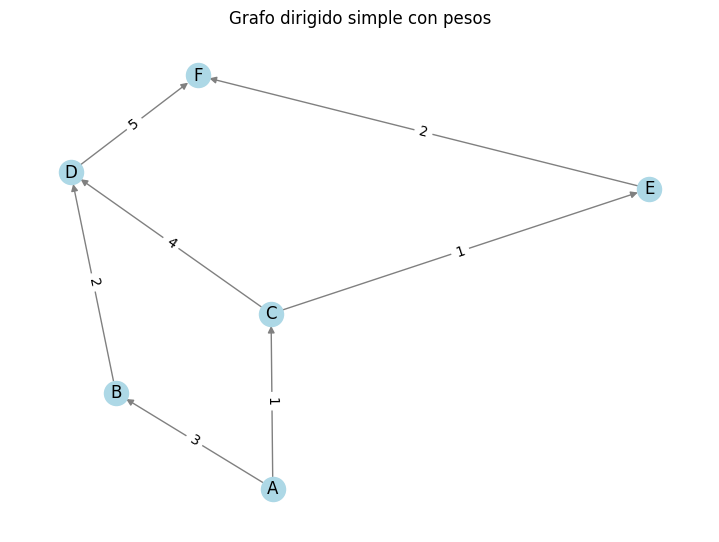

In [40]:
import networkx as nx
import matplotlib.pyplot as plt

# Dibujamos un grafo dirigido simple con pesos
# Este mismo grafo se usará en los recorridos siguientes
g = nx.DiGraph()
g.add_weighted_edges_from([
    ("A", "B", 3),
    ("A", "C", 1),
    ("B", "D", 2),
    ("C", "D", 4),
    ("C", "E", 1),
    ("D", "F", 5),
    ("E", "F", 2),
])

pos = nx.spring_layout(g, seed=42)
edge_labels = nx.get_edge_attributes(g, "weight")

plt.figure(figsize=(7, 5))
nx.draw(g, pos, with_labels=True, node_color='lightblue', edge_color='gray', arrows=True)
nx.draw_networkx_edge_labels(g, pos, edge_labels=edge_labels)
plt.title('Grafo dirigido simple con pesos')
plt.axis('off')

plt.show()

In [41]:
# Ejemplo de BFS (Breadth-First Search)
# Usamos el mismo grafo que dibujamos arriba
bfs_nodes = list(nx.bfs_tree(g, source="A"))
print('Recorrido BFS desde el nodo A:', bfs_nodes)


Recorrido BFS desde el nodo A: ['A', 'B', 'C', 'D', 'E', 'F']


In [42]:
# Ejemplo de DFS (Depth-First Search)
dfs_nodes = list(nx.dfs_tree(g, source="A"))
print('Recorrido DFS desde el nodo A:', dfs_nodes)

Recorrido DFS desde el nodo A: ['A', 'B', 'D', 'F', 'C', 'E']


In [43]:
# Ejemplo de Shortest Path (camino más corto)
# Calcula el camino más corto con pesos entre A y F
shortest_path = nx.shortest_path(g, source="A", target="F", weight="weight")
print('Camino más corto con pesos de A a F:', shortest_path)

Camino más corto con pesos de A a F: ['A', 'C', 'E', 'F']


## Ejemplo práctico de la web de google

In [44]:
def cargar_aristas_desde_archivo(ruta_archivo):

    lista_aristas = []
    print(f"Iniciando la lectura del archivo de aristas: {ruta_archivo}")

    with open(ruta_archivo, 'r') as archivo:
        # Saltamos la primera línea, que es el encabezado del archivo.
        next(archivo)

        # Procesamos cada línea subsiguiente que representa una arista.
        for i, linea in enumerate(archivo, start=1):
            partes = linea.strip().split()
            if len(partes) == 2:
                # Cada arista está formada por un nodo de origen y un nodo de destino.
                nodo_origen = int(partes[0])
                nodo_destino = int(partes[1])

                # Creamos una tupla para la arista y la añadimos a nuestra lista.
                arista = (nodo_origen, nodo_destino)
                lista_aristas.append(arista)

    print(f"Lectura completada. Se cargaron {len(lista_aristas)} aristas.")
    return lista_aristas


nombre_del_archivo_grafo = 'data/raw/web-Google.txt'
aristas = cargar_aristas_desde_archivo(nombre_del_archivo_grafo)

# Si la carga fue exitosa, imprimimos las primeras 5 aristas para verificar.
if aristas is not None:
    print("\n--- Primeras 5 aristas cargadas ---")
    print(aristas[:5])

Iniciando la lectura del archivo de aristas: data/raw/web-Google.txt
Lectura completada. Se cargaron 5105039 aristas.

--- Primeras 5 aristas cargadas ---
[(0, 11342), (0, 824020), (0, 867923), (0, 891835), (11342, 0)]


In [45]:
import networkx as nx

G = nx.DiGraph()
G.add_edges_from(aristas)

In [46]:
def get_max_in_degree_node(graph):
    max = 0
    maxNode = None
    for node in graph.nodes:
        if graph.in_degree(node) > max:
            max = graph.in_degree(node)
            maxNode = node
    return maxNode

maxNode = get_max_in_degree_node(G)
print(f"El nodo con mayor grado de entrada es: {maxNode} con un grado de entrada de {G.in_degree(maxNode)}")

El nodo con mayor grado de entrada es: 537039 con un grado de entrada de 6326
